# ITSM Kaplan-Meier Survival Model

Load the survival dataset produced by `create_itsm_survival_pipeline.ipynb`, estimate Kaplan-Meier curves by support group, and document the `kmds_modeling` spec question answers using `config.yaml`.

In [6]:
import pandas as pd
from pathlib import Path

from kmds_modeling import get_package_info, get_spec_questions

package_info = get_package_info()
requirements = {
    "project": {
        "task_type": "KAPLAN_MEIER"
    }
}
spec_questions = get_spec_questions(requirements)

package_info, spec_questions


({'package_name': 'kmds-modeling',
  'version': '0.6.1',
  'entry_points': {'kmds-modeling': 'kmds_modeling.cli:cli'},
  'cli_commands': ['evaluate', 'export'],
  'provided_packages': ['kmds_modeling'],
  'supported_models': ['TABULAR_CLASSIFICATION',
   'TABULAR_REGRESSION',
   'SURVIVAL_ANALYSIS'],
  'data_contract': {'model_ready_data_file': 'model_ready_numeric_data.csv',
   'featurization_output_dir': 'featurization',
   'default_model_ready_dataset_path': 'data/featurization/model_ready_numeric_data.csv',
   'modeling_output_dir': 'models',
   'note': 'This package assumes modeling input is produced to `data/featurization/` under the workspace working_dir. Featurization workflows should write outputs there for modeling to consume.'},
  'spec_discovery_note': 'Agents can discover task-specific required config by calling `get_spec_questions()` and building the model spec from those answers. Human users should make sure their design/prompt covers those questions before asking an age

In [ ]:
workspace_dir = Path.cwd()
project_root = workspace_dir if (workspace_dir / 'config.yaml').exists() else workspace_dir.parent
data_path = project_root / 'data' / 'dd_cleaner' / 'itsm_ticket_survival_dataset.csv'
if not data_path.exists():
    raise FileNotFoundError(f'Could not find survival dataset at {data_path}')

df = pd.read_csv(data_path)
df['incident_state'] = df['incident_state'].astype(str).str.lower()
df['duration_days'] = pd.to_numeric(df['duration_days'], errors='coerce')
group_counts = df['assignment_group'].value_counts()
valid_groups = group_counts[group_counts > 20].index.tolist()
slowest_groups = (
    df[df['assignment_group'].isin(valid_groups)]
    .groupby('assignment_group')['duration_days']
    .median()
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
summary = {
    'dataset_path': str(data_path),
    'rows': len(df),
    'assignment_groups': len(group_counts),
    'groups_over_20': len(valid_groups),
    'slowest_groups': slowest_groups,
}
summary

{'dataset_path': '/home/rajiv/programming/kmds_migration/itsm_analysis/data/dd_cleaner/itsm_ticket_survival_dataset.csv',
 'rows': 22652,
 'assignment_groups': 52,
 'groups_over_20': 52,
 'top_groups': {'Group 70': 9444,
  'Group 25': 1243,
  'Group 39': 1199,
  'Group 24': 1060,
  'Group 23': 811,
  'Group 64': 716,
  'Group 73': 576,
  'Group 28': 545,
  'Group 27': 518,
  'Group 20': 394,
  'Group 66': 376,
  'Group 72': 367,
  'Group 10': 343,
  'Group 65': 336,
  'Group 57': 313,
  'Group 55': 293,
  'Group 30': 268,
  'Group 29': 257,
  'Group 6': 257,
  'Group 22': 239}}

## Kaplan-Meier estimates by support group

This dataset is grouped by `assignment_group`. We compute Kaplan-Meier survival curves using `duration_days` and `survival_event` for support groups with more than 20 closure events.

In [8]:
from statsmodels.duration.survfunc import SurvfuncRight

km_rows = []
for group in valid_groups:
    group_df = df[df['assignment_group'] == group]
    time = group_df['duration_days'].values
    status = (group_df['survival_event'] == 1).astype(int).values
    sf = SurvfuncRight(time, status)
    km_group = pd.DataFrame({
        'assignment_group': group,
        'timeline': sf.surv_times,
        'survival': sf.surv_prob,
    })
    km_rows.append(km_group)

km_df = pd.concat(km_rows, ignore_index=True)
km_summary = km_df.groupby('assignment_group').agg(
    observations=('timeline', 'size'),
    min_duration=('timeline', 'min'),
    max_duration=('timeline', 'max'),
    final_survival=('survival', 'last'),
).reset_index()

output_dir = project_root / 'data' / 'dd_cleaner'
output_dir.mkdir(parents=True, exist_ok=True)
km_path = output_dir / 'itsm_ticket_survival_km_summary.csv'
km_df.to_csv(km_path, index=False)
km_summary.head(20)


,assignment_group,observations,min_duration,max_duration,final_survival
0,Group 10,335,5.009722,184.015278,0.0
1,Group 12,123,3.773611,76.175000,0.0
2,Group 13,36,0.006250,243.416667,0.0
3,Group 15,58,2.492361,263.789583,0.0
4,Group 19,37,5.036111,32.291667,0.0
5,Group 20,386,0.001389,230.288889,0.0
6,Group 21,58,5.019444,71.287500,0.0
7,Group 22,236,5.009722,166.959722,0.0
8,Group 23,687,4.027083,171.825000,0.0
9,Group 24,933,0.911806,203.035417,0.0


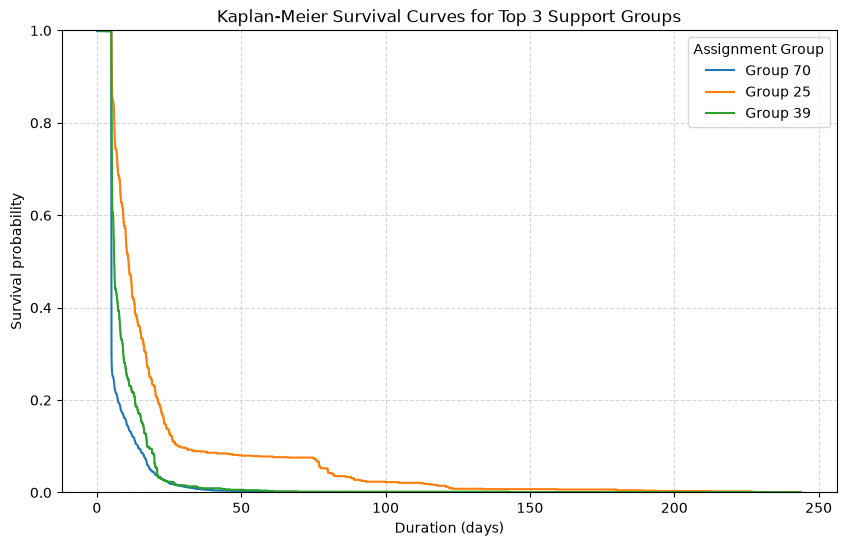

,assignment_group,observations,min_duration,max_duration,final_survival
0,Group 10,335,5.009722,184.015278,0.0
1,Group 12,123,3.773611,76.175000,0.0
2,Group 13,36,0.006250,243.416667,0.0
3,Group 15,58,2.492361,263.789583,0.0
4,Group 19,37,5.036111,32.291667,0.0
5,Group 20,386,0.001389,230.288889,0.0
6,Group 21,58,5.019444,71.287500,0.0
7,Group 22,236,5.009722,166.959722,0.0
8,Group 23,687,4.027083,171.825000,0.0
9,Group 24,933,0.911806,203.035417,0.0


In [ ]:
import matplotlib.pyplot as plt

slowest_groups = (
    df[df['assignment_group'].isin(valid_groups)]
    .groupby('assignment_group')['duration_days']
    .median()
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
fig, ax = plt.subplots(figsize=(10, 6))
for group in slowest_groups:
    group_curve = km_df[km_df['assignment_group'] == group]
    ax.step(group_curve['timeline'], group_curve['survival'], where='post', label=group)

ax.set_title('Kaplan-Meier Survival Curves for Slowest 3 Support Groups')
ax.set_xlabel('Duration (days)')
ax.set_ylabel('Survival probability')

ax.set_ylim(0, 1.0)

ax.grid(True, linestyle='--', alpha=0.5)km_summary

ax.legend(title='Assignment Group')
plt.show()

## Model spec question answers

Based on `config.yaml`, the KMDS modeling package capabilities, and the generated survival dataset, these are the answers for the required model spec fields.

In [10]:
spec_answers = {
    'project.task_type': 'KAPLAN_MEIER',
    'project.strategy': 'MAX_ACCURACY',
    'project.target_variable': 'duration_days',
    'project.user_intent': 'Estimate ticket closure survival curves by assignment group for ITSM incidents.',
    'project.name': 'ITSM Ticket Closure Kaplan-Meier Survival Analysis',
    'candidates': [
        {
            'name': 'kaplan_meier_support_group',
            'class_path': 'lifelines.KaplanMeierFitter',
            'hyperparameters': {},
        }
    ],
    'production_target.champion_candidate_name': 'kaplan_meier_support_group',
    'production_target.export_directory': 'models',
}
spec_answers


{'project.task_type': 'KAPLAN_MEIER',
 'project.strategy': 'MAX_ACCURACY',
 'project.target_variable': 'duration_days',
 'project.user_intent': 'Estimate ticket closure survival curves by assignment group for ITSM incidents.',
 'project.name': 'ITSM Ticket Closure Kaplan-Meier Survival Analysis',
 'candidates': [{'name': 'kaplan_meier_support_group',
   'class_path': 'lifelines.KaplanMeierFitter',
   'hyperparameters': {}}],
 'production_target.champion_candidate_name': 'kaplan_meier_support_group',
 'production_target.export_directory': 'models'}